In [47]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import importlib
import seaborn as sns

In [48]:
data = pd.read_csv("data_set.csv")
data.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [49]:
df = data.copy()
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [50]:
df.shape

(7560, 6)

In [51]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [52]:
df.dtypes

Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [54]:
df.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [55]:
df.isna()

,Date,Time,State,Group,Unit,Sales
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
7555,False,False,False,False,False,False
7556,False,False,False,False,False,False
7557,False,False,False,False,False,False
7558,False,False,False,False,False,False


In [56]:
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [57]:
df.notna()

,Date,Time,State,Group,Unit,Sales
0,True,True,True,True,True,True
1,True,True,True,True,True,True
2,True,True,True,True,True,True
3,True,True,True,True,True,True
4,True,True,True,True,True,True
...,...,...,...,...,...,...
7555,True,True,True,True,True,True
7556,True,True,True,True,True,True
7557,True,True,True,True,True,True
7558,True,True,True,True,True,True


In [58]:
df.notna().sum()

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date     datetime64[ns]
Time             object
State            object
Group            object
Unit              int64
Sales             int64
dtype: object

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Sales", "Unit"]] = scaler.fit_transform(df[['Sales', 'Unit']])

df.head()

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873


In [63]:
df.groupby("State")["Sales"].sum()

State
NSW    441.714286
NT     109.079365
QLD    177.888889
SA     339.412698
TAS    110.222222
VIC    635.968254
WA     106.365079
Name: Sales, dtype: float64

In [64]:
df.groupby("Group")["Sales"].mean()

Group
Kids       0.254044
Men        0.256320
Seniors    0.250567
Women      0.255287
Name: Sales, dtype: float64

In [65]:
df["Sales"].describe()
df["Unit"].describe()

mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
std_sales = df["Sales"].std()
mode_sales = df["Sales"].mode()

print("Sales Describe")
print("Sales Mean : ", mean_sales)
print(f"Sales Median : {median_sales}")
print(f"Sales Std : {std_sales}")
print(f"Sales Mode : {mode_sales}")

mean_unit = df["Unit"].mean()
median_unit = df["Unit"].median()
std_unit = df["Unit"].std()
mode_unit = df["Unit"].mode()

print("\nUnit Describe")
print(f"Unit Mean : {mean_unit}")
print(f"Unit Median : {median_unit}")
print(f"Unit Std : {std_unit}")
print(f"Unit Mode : {mode_unit}")

Sales Describe
Sales Mean :  0.25405433778449654
Sales Median : 0.1904761904761905
Sales Std : 0.2047841710728009
Sales Mode : 0    0.111111
Name: Sales, dtype: float64

Unit Describe
Unit Mean : 0.2540543377844965
Unit Median : 0.19047619047619047
Unit Std : 0.20478417107280086
Unit Mode : 0    0.111111
Name: Unit, dtype: float64


In [66]:
group_sales = df.groupby("Group")["Sales"].sum()
highest_group = group_sales.idxmax()
lowest_group = group_sales.idxmin()
print(f"Group for Highest Sales : {highest_group}")
print(f"Group for Lowest Sales : {lowest_group}")

Group for Highest Sales :  Men
Group for Lowest Sales :  Seniors


In [67]:
state_sales = df.groupby("State")["Sales"].sum()
highest_state = state_sales.idxmax()
lowest_state = state_sales.idxmin()
print(f"State for Highest Sales : {highest_state}")
print(f"State for Lowest Sales : {lowest_state}")

State for Highest Sales :  VIC
State for Lowest Sales :  WA


In [68]:
df["Week"] = df["Date"].dt.isocalendar().week
weekly = df.groupby("Week")["Sales"].sum()
weekly

Week
40     84.857143
41    152.777778
42    150.476190
43    151.587302
44    122.460317
45    113.809524
46    115.761905
47    115.380952
48    117.698413
49    169.412698
50    181.492063
51    182.317460
52    183.047619
53     79.571429
Name: Sales, dtype: float64

In [69]:
df["Month"] = df["Date"].dt.month 
monthly = df.groupby("Month")["Sales"].sum()
monthly

Month
10    645.650794
11    495.761905
12    779.238095
Name: Sales, dtype: float64

In [70]:
df["Quarter"] = df["Date"].dt.quarter 
quarterly = df.groupby("Quarter")["Sales"].sum()
quarterly

Quarter
4    1920.650794
Name: Sales, dtype: float64

In [71]:
df["Hour"] = df["Date"].dt.hour
hourely = df.groupby("Hour")["Sales"].sum()
hourely

Hour
0    1920.650794
Name: Sales, dtype: float64

In [72]:
df.head()

,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter,Hour
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,40,10,4,0
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,40,10,4,0
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,40,10,4,0
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,40,10,4,0
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,40,10,4,0


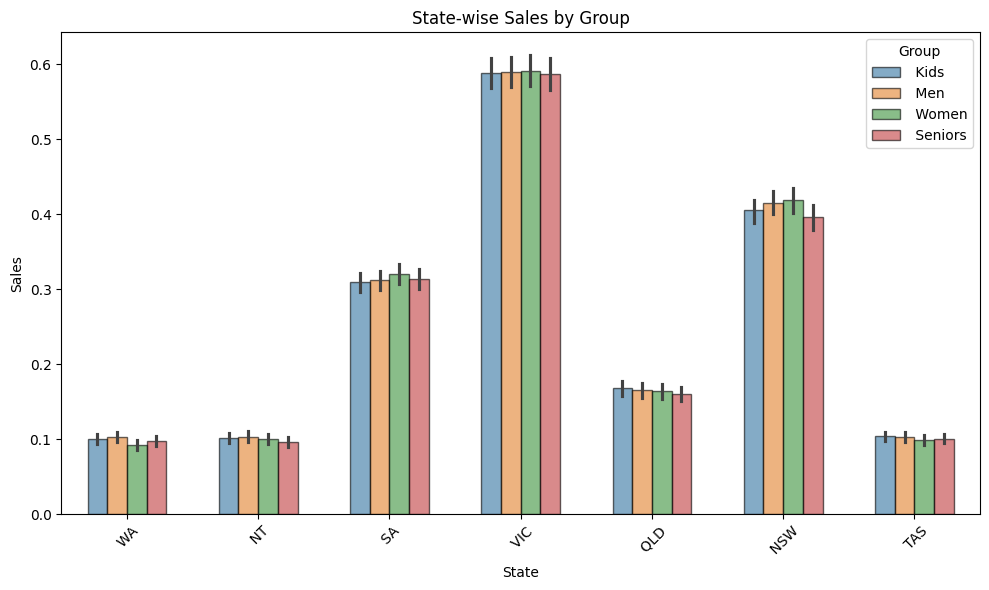

In [73]:
importlib.reload(plt)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='State', y='Sales', hue='Group', width=0.6, alpha=0.6, edgecolor="black")
plt.title("State-wise Sales by Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Group_Wise Sales Distribution')

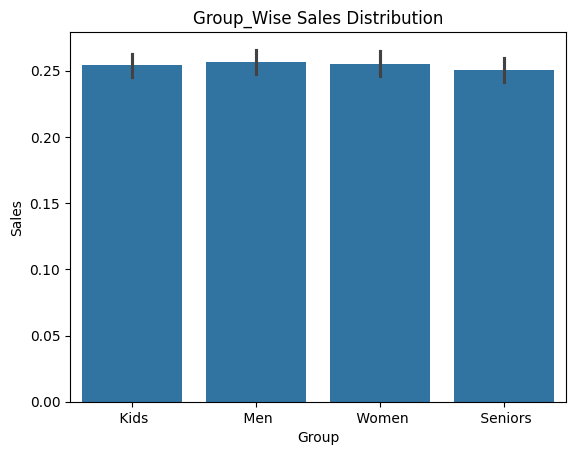

In [74]:
sns.barplot(data=df, x="Group", y="Sales")
plt.title("Group_Wise Sales Distribution")

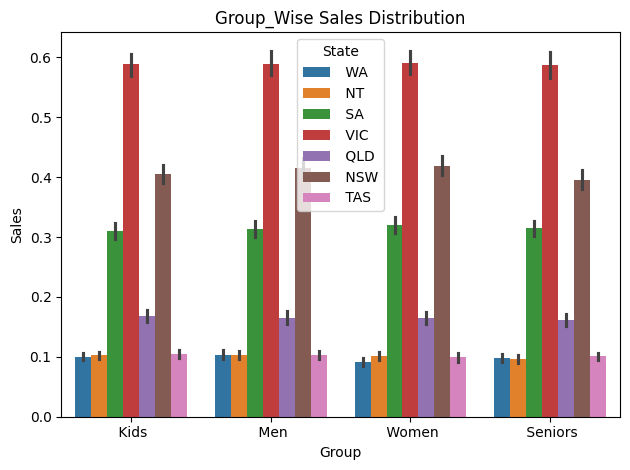

In [75]:
sns.barplot(data=df, x="Group", y="Sales", hue="State")
plt.title("Group_Wise Sales Distribution")
plt.tight_layout()

<Axes: xlabel='Time', ylabel='Sales'>

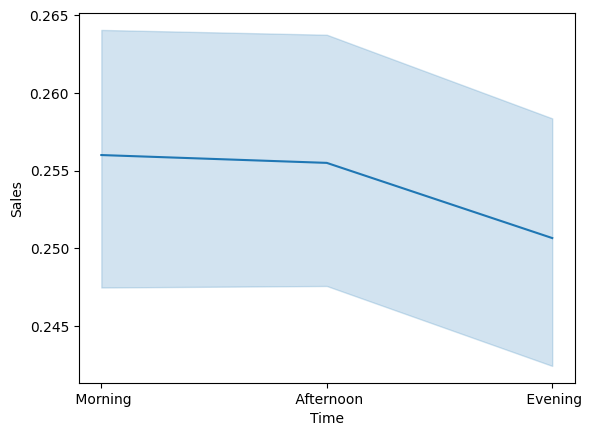

In [76]:
sns.lineplot(data=df, x="Time", y="Sales")

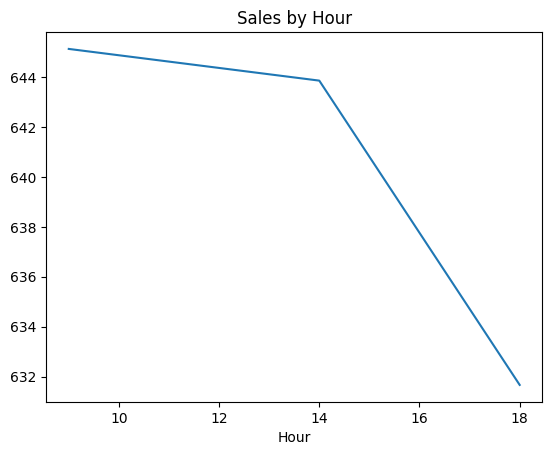

In [79]:
sns.lineplot(x=time_sales.index, y=time_sales.values)
plt.title("Sales by Hour")
plt.show()

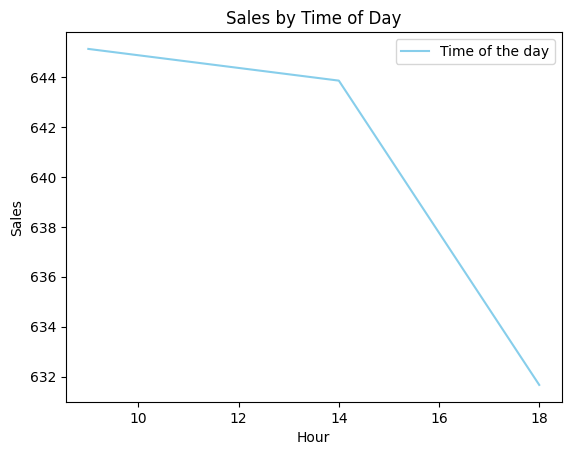

In [80]:
time_map = {
    " Morning" : 9, 
    " Afternoon" : 14, 
    " Evening" : 18, 
    " Night" : 21
}


df["Hour"] = df["Time"].map(time_map)

time_sales = df.groupby("Hour")["Sales"].sum()
sns.lineplot(x=time_sales.index, y=time_sales.values, 
            label="Time of the day", color="skyblue")
plt.title("Sales by Time of Day")
plt.xlabel("Hour")
plt.ylabel("Sales")
plt.legend()
plt.show()

<Axes: title={'center': 'Weekly Sales Trend'}, xlabel='Week'>

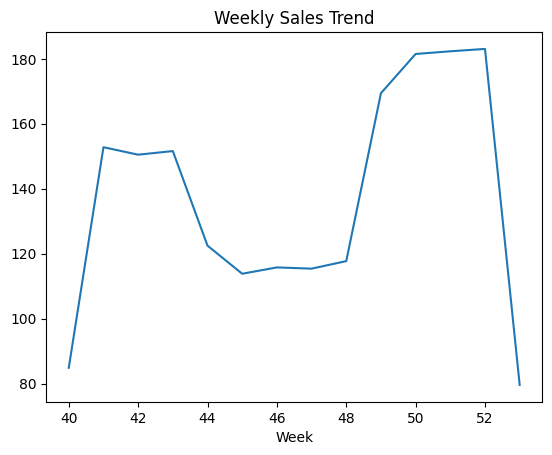

In [81]:
weekly.plot(kind="line", title="Weekly Sales Trend")

<Axes: title={'center': 'Monthly Sales'}, xlabel='Month'>

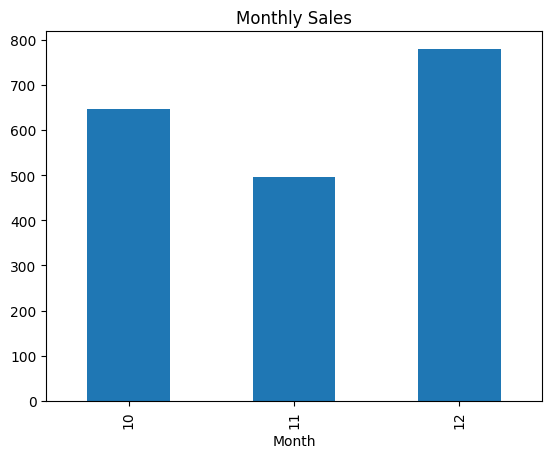

In [82]:
monthly.plot(kind="bar", title="Monthly Sales")

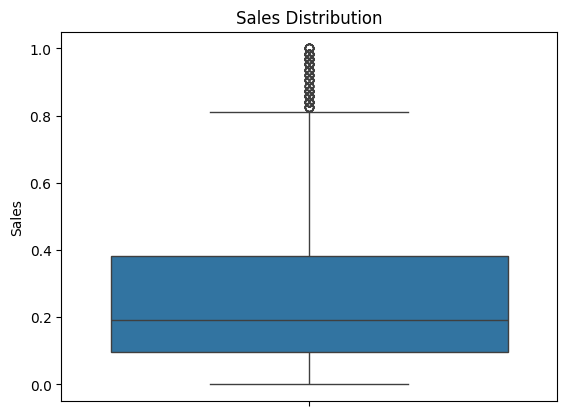

In [83]:
sns.boxplot(data=df['Sales'])
plt.title("Sales Distribution")
plt.show()

C:\Users\roush\AppData\Local\Temp\ipykernel_15852\1097041661.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df, x="Sales", kde=True, palette="rainbow", edgecolor="black", bins=25)


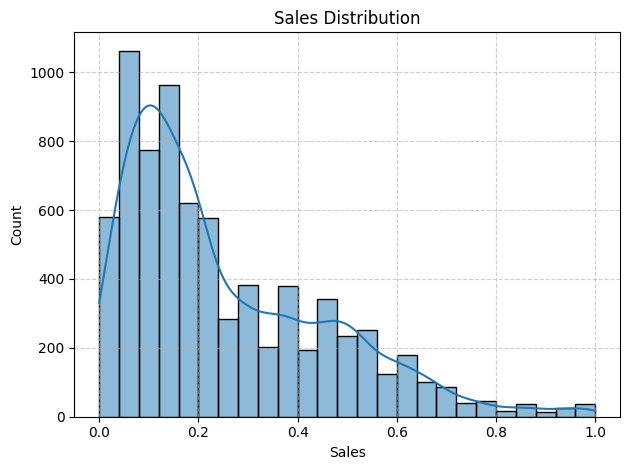

In [84]:
sns.histplot(data = df, x="Sales", kde=True, palette="rainbow", edgecolor="black", bins=25)
plt.title("Sales Distribution")
plt.tight_layout()
plt.grid(linestyle="--", alpha=0.6)